# TensorFlow 核心概念

------

## 张量(Tensor)
张量是 TensorFlow 中的基本数据结构。它是一个多维数组，可以包含各种类型的数据，如整数、浮点数、字符串等。张量具有以下属性：
- 维度(Dimension)：张量的维度表示它的轴数。例如，一个标量是0维张量，一个向量是一维张量，一个矩阵是二维张量，依此类推。
- 形状(Shape)：张量的形状表示每个维度的大小。例如，一个形状为(3, 4)的张量表示一个3行4列的矩阵。
- 数据类型(Datatype)：张量的数据类型表示它包含的数据类型。例如，tf.float32表示32位浮点数，tf.int32表示32位整数，tf.string表示字符串等。

**简单类比:**
- 标量(Scalar)：一个单一的数值，例如5或3.14。
- 向量(Vector)：一个数值的列表，例如[1, 2, 3]。
- 矩阵(Matrix)：一个数值的二维数组，例如[[1, 2], [3, 4]]。
- 3维张量 : 数字的立方体 , 如彩色图像 (高度 x 宽度 x 颜色通道)。
- 更高维张量 : 可以表示更复杂的数据结构，如视频(帧数 x 高度 x 宽度 x 颜色通道)。

#### 张量的关键属性

In [1]:
# 示例张量
import tensorflow as tf
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 只显示错误信息

# 创建一个 2 * 3 的矩阵向量
tensor = tf.constant([[1, 2, 3], [4, 5, 6]])

print(f"形状(Shape): {tensor.shape}")
print(f"数据类型(Dtype): {tensor.dtype}")
print(f"数据(Data): \n{tensor}")
print(f"维度(Rank): {tf.rank(tensor)}")
print(f"设备(Device): {tensor.device}")

I0000 00:00:1777826008.430809 1106260 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777826008.494052 1106260 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777826010.733471 1106260 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


形状(Shape): (2, 3)
数据类型(Dtype): <dtype: 'int32'>
数据(Data): 
[[1 2 3]
 [4 5 6]]
维度(Rank): 2
设备(Device): /job:localhost/replica:0/task:0/device:CPU:0


E0000 00:00:1777826011.939783 1106260 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


##### 关键属性解释

**形状(Shape):** 描述每个维度的大小

**数据类型(Datatype):** 描述张量中元素的数据类型

**维度(Dimension)/秩(Rank):** 描述张量的轴数

**设备(Device):** 张量存储的设备位置

-------

## 计算图(Computational Graph)
计算图是一种用节点和边来表示数学运算的图结构:
- 节点(Node)：代表数学运算(加法 , 乘法 , 激活函数等)。
- 边(Edge)：代表数据流动的路径，连接输入和输出张量。

**简单例子**
计算 z = (x + y) * w 的计算图：

```
x ──┐
    ├─→ [+] ──→ [×] ──→ z
y ──┘         ├
w ────────────┘
```

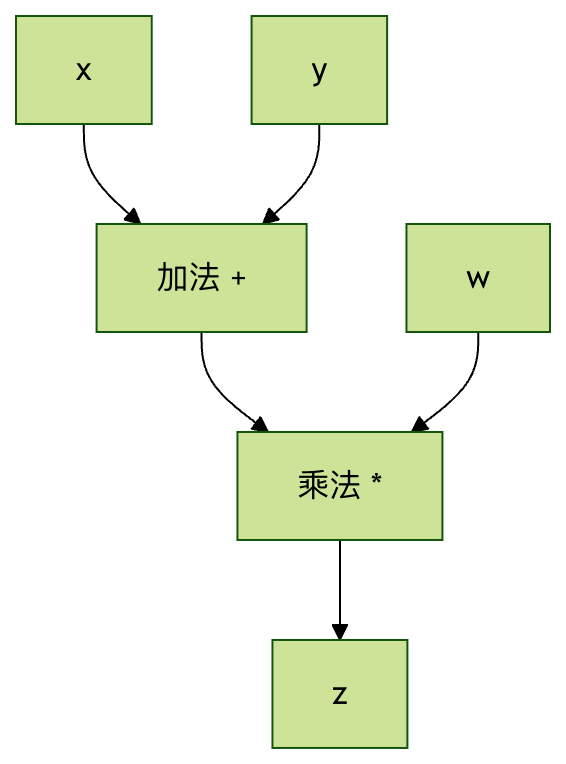


-----

### 计算图的优势

#### 1. 自动微分
- 可以自动计算梯度 , 实现反向传播算法 , 方便训练神经网络。
- 不需要手动计算复杂的导数 , 提高效率和准确性。

#### 2. 优化机会
- 编译时优化 : 合并运算 , 消除冗余计算 , 提高性能。
- 运行时优化 : 内存复用 , 并行计算 , 加速训练和推理。

#### 3. 可视化调试
- 可以使用 TensorBoard 可视化计算图 , 监控训练过程 , 调试模型。
- 帮助理解模型结构和数据流动 , 发现潜在问题。

#### 4. 分布式计算
- 可以在多个设备(如GPU , TPU)上分布式执行计算图 , 加速训练大规模模型。
- 支持大规模数据和模型的训练 , 提高效率。

In [2]:
# TensorFlow 动态图/即时执行
import tensorflow as tf

# 直接执行运算
x = tf.constant([
    [1.0 , 2.0 , 3.0]
])

W = tf.Variable(tf.random.normal([3 , 2]))
b = tf.Variable(tf.zeros([2]))
y = tf.matmul(x , W) + b

print(f"输出结果: {y}")

输出结果: [[2.7247543 7.584302 ]]


-------

## 即时执行(Eager Execution)
即时执行是一种动态计算模式 , 允许在 Python 中直接执行 TensorFlow 操作 , 而不需要构建计算图。

**即时执行的特点:**
- 立即求值 : 操作会立即执行并返回结果 , 方便调试和交互式开发。
- 易于调试 : 可以使用 Python 的调试工具 , 逐步执行代码 , 检查变量值。
- 直观编程 : 代码更接近普通的 Python 代码 , 更易于理解和编写。

In [3]:
# TensorFlow 2.x - 即时执行
import tensorflow as tf

a = tf.constant(2.0)
b = tf.constant(3.0)
c = a + b
print(f"结果: {c}")  # 结果: 5.0

# 可以直接访问值
print(f"c 的 numpy 值: {c.numpy()}")  # c 的 numpy 值: 5.0

结果: 5.0
c 的 numpy 值: 5.0


### 图模式 vs 即时执行模式
#### 即时执行模式(默认 , 适合调试和交互式开发)
- 运算立即执行 , 结果直接返回。
- 代码更直观 , 更接近普通 Python 代码。
- 适合调试和快速原型开发。

#### 图模式(需要使用 @tf.function 装饰器 , 适合生产环境和性能优化)
- 需要显式构建计算图 , 运算在图中执行。
- 代码更接近 TensorFlow 1.x 的风格 , 需要理解计算图的概念。
- 适合生产环境和性能优化 , 可以利用计算图的优势进行优化和分布式计算。

In [27]:
@tf.function
def compute_function(x , y):
    return x * y + x

# 这个函数会被编译成 TensorFlow 图
result = compute_function(tf.constant(2.0) , tf.constant(3.0))
print(f"计算结果: {result}")  # 计算结果: 8.0

计算结果: 8.0


--------

## 变量(Variable) 和 常量(Constant)

### 常量(Constant)
常量是不可变的张量 , 一旦创建就不能修改。它们通常用于存储模型的超参数或固定的输入数据。

In [4]:
# 创建常量
scalar_const = tf.constant(3.14)
vector_const = tf.constant([1.0 , 2.0 , 3.0])
matrix_const = tf.constant([[1 , 2] , [3 , 4]])

# 常量的值不能改变
print(scalar_const)

tf.Tensor(3.14, shape=(), dtype=float32)


#### 常量的用途
- 存储超参数(学习率 , 批大小等)
- 存储不需要训练的配置数据
- 作为计算中的固定值

### 变量(Variable)
变量是可变的张量 , 通常用来存储模型参数

In [29]:
# 创建变量
weight = tf.Variable(tf.random.normal([2 , 3]))
bias = tf.Variable(tf.zeros([3]))

print(f"初始权重\n: {weight}")

# 修改变量的值
weight.assign(tf.ones([2 , 3]))
print(f"修改后的权重\n: {weight}")

# 部分更新
weight[0 , 0].assign(5.0)
print(f"部分更新后的权重\n: {weight}")

初始权重
: <tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[-0.77834815,  2.150087  ,  2.3074658 ],
       [ 1.4554589 , -1.6455352 , -0.85623676]], dtype=float32)>
修改后的权重
: <tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>
部分更新后的权重
: <tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[5., 1., 1.],
       [1., 1., 1.]], dtype=float32)>


##### 变量的关键特性
- 状态保持 : 在训练过程中保持状态 , 可以更新和修改。
- 可优化 : 可以被优化器更新 , 适合存储需要训练的参数。
- 可保存 : 可以保存到检查点文件
- 梯度跟踪 : 可以跟踪梯度 , 参与自动微分和优化过程。

In [30]:
# 前向传播
import tensorflow as tf

# 输入数据
x = tf.constant([[1.0 , 2.0]])

# 模型参数
W1 = tf.Variable(tf.random.normal([2 , 3]))
b1 = tf.Variable(tf.zeros([3]))
W2 = tf.Variable(tf.random.normal([3 , 1]))
b2 = tf.Variable(tf.zeros([1]))

# 隐藏层
hidden = tf.matmul(x , W1) + b1
output = tf.matmul(hidden , W2) + b2

print(f"输出结果: {output}")

输出结果: [[-2.4430764]]


In [ ]:
# 自动微分
x = tf.Variable(3.0)

# 使用 GradientTape 记录计算过程
with tf.GradientTape() as tape:
    y = x ** 2 + 2 * x + 1

# 计算梯度
dy_dx = tape.gradient(y, x)
print(f"梯度: {dy_dx}")

梯度: 8.0


##### GradientTape 的工作原理:
- 1. 记录运算 : tape 记录在上下文中执行的所有操作 , 以便后续计算梯度。
- 2. 构建反向图 : tape 构建一个反向图 , 以便在计算梯度时使用。
- 3. 计算梯度 : 使用 tape.gradient() 方法计算目标张量相对于源张量的梯度。
- 4. 释放资源 : 计算完成后 , tape 会自动释放资源 , 以节省内存。

In [6]:
# 完整的训练步骤示例
import tensorflow as tf

# 模型和数据
# 这里设置了一个模型 , 隐藏层有10个神经元   , 激活函数是relu , 输出层是1
# relu 是 f(x) = max(0 , x)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1)
])

x_train = tf.random.normal([100 , 5])     # 生成了一个形状为 (100 , 5) 的张量 , 100 : 样本数量(行数) , 5 : 每个样本的特征数量(列数) , 数值服从标准正态分布
y_train = tf.random.normal([100 , 1])

# 创建了一个 Adam 优化器 , 学习率为 0.01
optimizer = tf.keras.optimizers.Adam(0.01)

# 训练步骤
@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        predictions = model(x)
        loss = tf.keras.losses.mse(y , predictions)

    # tape.gradient(target , sources)
        # target : 目标值 , 通常是loss(损失)
        # sources : 要求梯度的对象(所有可训练对象)
    gradients = tape.gradient(loss , model.trainable_variables)
    optimizer.apply_gradients(zip(gradients , model.trainable_variables))
    return loss

# 执行
for epoch in range(10):
    loss = train_step(x_train, y_train)
    print(f"Epoch{epoch} : Loss = {loss}")

Epoch0 : Loss = [3.21124822e-01 7.29970485e-02 1.52609900e-01 3.16595495e-01
 2.69810677e-01 9.90935802e-01 3.33444476e+00 1.72202010e-03
 2.05472517e+00 8.79729748e-01 9.71605256e-02 2.99626030e-02
 1.35379922e+00 2.06634507e-01 1.90702450e+00 7.95531034e-01
 3.19094253e+00 8.46533943e-03 5.50693236e-02 5.34731674e+00
 1.82401896e+00 4.39343929e-01 3.44850086e-02 1.94161725e+00
 1.61557884e+01 3.67688131e+00 2.04992816e-01 6.42745793e-01
 4.81870724e-03 4.26716614e+00 4.26835108e+00 6.03358173e+00
 1.75516140e+00 8.15314706e-03 2.10098839e+00 1.00912333e+00
 6.34423867e-02 1.62004280e+00 5.18267775e+00 1.81268200e-01
 4.66398764e+00 1.98597085e+00 4.00086880e+00 5.01723588e-02
 4.72166725e-02 3.35824676e-02 7.90951252e-02 3.93004370e+00
 1.37486696e+01 1.19506943e+00 6.61861226e-02 2.24572137e-01
 3.80071104e-02 2.14409985e-04 3.60691786e-01 2.30272324e-03
 7.01723911e-05 6.26040876e-01 1.26365453e-01 3.63515466e-01
 2.95313978e+00 1.82741154e-02 4.14983839e-01 4.71449566e+00
 7.77431

### 全连接层的特征压缩 (Compression)

当我们使用 `Dense(1)` 作为输出层时，它将前一层所有神经元的输出合并为一个标量。
这**不是简单的相加或平均**，而是**可学习的加权求和**。

#### 1. 核心公式
假设隐藏层有 10 个神经元，输出向量为 $X$，输出层计算结果 $y$ 的公式为：

$$ y = X \cdot W + b $$

展开后即为：

$$ y = (x_1 \times w_1) + (x_2 \times w_2) + \dots + (x_{10} \times w_{10}) + b $$

#### 2. 参数含义
- **$X$**：隐藏层的输出向量，形状为 `(10,)`。
- **$W$**：权重向量，形状为 `(10, 1)`。由模型在训练中自动学习得出，决定每个神经元对最终结果的重要性。
- **$b$**：偏置标量，形状为 `(1,)`。

## 核心概念总结

```
输入数据 (Tensor) ──→ 计算图 (Graph) ──→ 输出结果 (Tensor)
      ↑                    ↓
   常量/变量            前向传播
      ↑                    ↓
   参数存储 ←──── 梯度更新 ←──── 自动微分
                              ↑
                        GradientTape

```

## 模型权重自动学习原理

### 1. 核心思想
模型"学习"的本质就是通过不断调整权重 $W$ 和偏置 $b$，使预测值尽可能接近真实值。

### 2. 完整训练流程

#### 步骤 1: 前向传播 (Forward Propagation)
输入数据通过网络层逐层计算，得到预测值：
$$ \hat{y} = f(x; W, b) $$

#### 步骤 2: 计算损失 (Loss Computation)
用损失函数衡量预测值与真实值的差距：
$$ L = \text{MSE}(y, \hat{y}) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 $$

#### 步骤 3: 反向传播 (Backpropagation)
使用 `GradientTape` 计算损失对每个参数的梯度：
$$ \nabla W = \frac{\partial L}{\partial W}, \quad \nabla b = \frac{\partial L}{\partial b} $$

#### 步骤 4: 参数更新 (Parameter Update)
优化器根据梯度调整参数，核心公式（梯度下降）：
$$ W_{new} = W_{old} - \eta \cdot \nabla W $$
$$ b_{new} = b_{old} - \eta \cdot \nabla b $$

| 符号 | 含义 |
| :--- | :--- |
| $W_{old}$ | 更新前的权重 |
| $W_{new}$ | 更新后的权重 |
| $\eta$ | 学习率 (Learning Rate)，如 `0.01` |
| $\nabla W$ | 梯度（损失对权重的偏导数） |

### 3. 梯度的物理意义

- **梯度为正**：说明增大该参数会导致 Loss 增大 → 应**减小**该参数
- **梯度为负**：说明增大该参数会导致 Loss 减小 → 应**增大**该参数
- **梯度绝对值大**：说明该参数对 Loss 影响敏感 → 需要**大幅调整**
- **梯度绝对值小**：说明该参数对 Loss 影响微弱 → 只需**微调**

### 4. 可视化理解

想象站在山上蒙着眼睛，想要走到山谷最低点：
- **Loss** = 当前海拔高度
- **梯度** = 脚下最陡的下坡方向
- **学习率** = 每一步迈出的步长
- **参数更新** = 沿着梯度反方向走一步

### 5. Adam 优化器的改进

基础梯度下降的缺点：学习率固定，可能震荡或收敛慢。

**Adam 优化器** 的优势：
- 自适应调整每个参数的学习率
- 结合动量 (Momentum) 加速收敛
- 公式简化理解：
  $$ W_{new} = W_{old} - \frac{\eta}{\sqrt{v} + \epsilon} \cdot m $$
  其中 $m$ 是一阶矩估计（均值），$v$ 是二阶矩估计（方差）